# Análise Exploratória de Dados

Este projeto é parte da Residência em Inteligência Artificial Avançada do [Instituto de Pesquisas ELDORADO (Brazil)](https://www.eldorado.org.br/).
Neste projeto, o objetivo é realizar uma análise exploratória de dados utilizando técnicas de Data Mining e Visualização de Dados.

##### © 2026, KALOMBOLA, C. M;

O conteúdo deste projeto é licenciado <a href="https://creativecommons.org/licenses/by/4.0/deed.fr" target='_blank'>Creative Commons Attribution 4.0 (CC BY 4.0)</a>,<br/>e os código estão em <a href="https://www.apache.org/licenses/LICENSE-2.0" target='_blank'>licence Apache 2.0</a>.

#### **Fonte dos dados**
Os dados originais sobre mensagens de golpes financeiros (smishing) e mensagens legítimas são provenientes da plataforma Hugging Face

#### **Dicionário de dados**
* **id**: identificador do registro
* **fonte**: origem da mensagem
* **texto**: conteúdo da mensagem
* **classe**: rótulo da mensagem

### **Tópicos**

1. Importação de bibliotecas e leitura dos dados
2. Caracterização geral do dataset
3. Verificação de duplicatas
4. Engenharia de atributos
5. Estatística descritiva
6. Padrões e tendências visuais
7. Análise de correlação
8. Conclusões
9. Registro de alterações da fusão

## 1. Importação de bibliotecas e leitura dos dados

In [1]:
import pandas as pd
import numpy as np
import re
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sb
from wordcloud import WordCloud

from scipy import stats
from sklearn.feature_selection import mutual_info_classif

In [2]:
pd.set_option("display.max_colwidth", 120)
sb.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

In [3]:
caminho_csv = "/content/dataset2_limpo (1).csv"

df = pd.read_csv(caminho_csv)

In [4]:
print("Dimensão:", df.shape)

Dimensão: (3405, 4)


In [5]:
display(df.head())

,id,fonte,texto,classe
0,1_0,sms,"Oi, peço para transferir aquele valor para meu mpesa. Este mesmo número",Legitimate
1,2_0,sms,Bom dia babe..tudo bem? Não se esqueça de ligar pra o seu tio e seu boss...as 09h. Bj,Legitimate
2,3_0,sms,AEN8AFWXJHC Confirmado. Compraste 19.00MT de credito aos 23/5/23 as 6:23 PM.O novo saldo M-Pesa e de 0.38MT. Em caso...,Legitimate
3,4_0,sms,"7GD04E51YZM. Caro Cliente, o codigo para efectuar levantamento na conta M-Pesa e 639850. Tens 15min para usa-lo na A...",Legitimate
4,5_0,sms,Bom dia babe. Está bem. Vou comprar. Boa viagem,Legitimate


## 2. Caracterização geral do dataset

In [6]:
print("Tipos das variáveis:")
display(df.dtypes)

Tipos das variáveis:


,0
id,object
fonte,object
texto,object
classe,object


In [7]:
print("Valores ausentes:")
display(df.isnull().sum())

Valores ausentes:


,0
id,0
fonte,0
texto,0
classe,0


In [8]:
print("Distribuição das classes:")
display(df["classe"].value_counts())

Distribuição das classes:


,count
classe,
Legitimate,2009
Smishing,1396


In [9]:
print("Proporção das classes (%):")
display((df["classe"].value_counts(normalize=True) * 100).round(2))

Proporção das classes (%):


,proportion
classe,
Legitimate,59.0
Smishing,41.0


In [10]:
print("Distribuição das fontes:")
display(df["fonte"].value_counts())

Distribuição das fontes:


,count
fonte,
sms,3005
fb,400


In [12]:
class_distribution = df["classe"].value_counts()
class_distribution

,count
classe,
Legitimate,2009
Smishing,1396


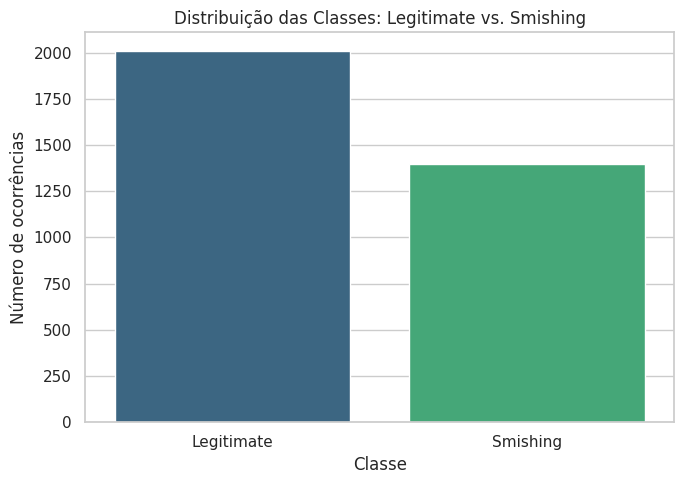

In [13]:
plt.figure(figsize=(7, 5))
sb.barplot(
    x=class_distribution.index, y=class_distribution.values,
    hue=class_distribution.index, palette="viridis", legend=False
)
plt.title("Distribuição das Classes: Legitimate vs. Smishing")
plt.xlabel("Classe")
plt.ylabel("Número de ocorrências")
plt.tight_layout()
plt.show()

## 3. Verificação de duplicatas

In [14]:
duplicadas = df[df["texto"].duplicated(keep=False)].copy()

print("Registros envolvidos em duplicatas:", len(duplicadas))

Registros envolvidos em duplicatas: 10


In [15]:
display(duplicadas[["id", "fonte", "texto", "classe"]].sort_values("texto"))

,id,fonte,texto,classe
2159,157_1,sms,"Aquele Valor Podes Transferir Para Esta Conta 858485917, Via M-pesa Ou Ponto24, Vem O Nome De Omar Baptista Mg",Smishing
2555,616_1,sms,"Aquele Valor Podes Transferir Para Esta Conta 858485917, Via M-pesa Ou Ponto24, Vem O Nome De Omar Baptista Mg",Smishing
549,558_0,sms,"Boa tarde, podes enviar aquele valor para este nr850275263. Tem M-pesa esta em nome de enobre eduardo",Legitimate
2426,459_1,sms,"Boa tarde, podes enviar aquele valor para este nr850275263. Tem M-pesa esta em nome de enobre eduardo",Smishing
1524,1555_0,sms,Bom dia O Valor Manda Para Esse Numero 846772707 M-pesa Esta Em Nome De ALFAN JOÄNQUE EMILIO!!,Legitimate
2221,223_1,sms,Bom dia O Valor Manda Para Esse Numero 846772707 M-pesa Esta Em Nome De ALFAN JOÄNQUE EMILIO!!,Smishing
2210,212_1,sms,ESSE VALOR MANDAR ESTE NUMERO 857426561 NOME DE M-Pesa LURDES PAULO DOBO,Smishing
2365,383_1,sms,ESSE VALOR MANDAR ESTE NUMERO 857426561 NOME DE M-Pesa LURDES PAULO DOBO,Smishing
1303,1329_0,sms,"Manda o valor neste número,858148365.M-pesa vem em nome da Sara José Vinte Ok.",Legitimate
2461,503_1,sms,"Manda o valor neste número,858148365.M-pesa vem em nome da Sara José Vinte Ok.",Smishing


As 10 duplicatas de texto (5 pares) recebem rótulos **diferentes** nos dois
registros de cada par (uma cópia `Legitimate`, outra `Smishing`)

## 4. Engenharia de atributos



### 4.1 Tamanho e composição do texto

In [20]:
# Quantidade de caracteres
df["qtd_caracteres"] = df["texto"].str.len()


In [19]:
# Quantidade de palavras
df["qtd_palavras"] = df["texto"].str.split().str.len()

In [21]:
# Quantidade de números/dígitos
df["qtd_numeros"] = df["texto"].apply(lambda x: len(re.findall(r"\d", str(x))))

In [22]:
# Quantidade de símbolos
df["qtd_simbolos"] = df["texto"].apply(lambda x: len(re.findall(r"[^\w\s]", str(x))))

In [23]:
# Quantidade de links (contagem, não só presença)
df["qtd_links"] = df["texto"].apply(lambda x: len(re.findall(r"http\S+", str(x))))

In [24]:
# Quantidade de emojis
df["qtd_emojis"] = df["texto"].apply(
    lambda x: len(re.findall(
        r"[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF\U0001F680-\U0001F6FF\U0001F1E0-\U0001F1FF]",
        str(x)
    ))
)

In [25]:
df

,id,fonte,texto,classe,qtd_caracteres,qtd_palavras,qtd_numeros,qtd_simbolos,qtd_links,qtd_emojis
0,1_0,sms,"Oi, peço para transferir aquele valor para meu mpesa. Este mesmo número",Legitimate,71,12,0,2,0,0
1,2_0,sms,Bom dia babe..tudo bem? Não se esqueça de ligar pra o seu tio e seu boss...as 09h. Bj,Legitimate,85,18,2,7,0,0
2,3_0,sms,AEN8AFWXJHC Confirmado. Compraste 19.00MT de credito aos 23/5/23 as 6:23 PM.O novo saldo M-Pesa e de 0.38MT. Em caso...,Legitimate,153,26,19,13,0,0
3,4_0,sms,"7GD04E51YZM. Caro Cliente, o codigo para efectuar levantamento na conta M-Pesa e 639850. Tens 15min para usa-lo na A...",Legitimate,189,32,21,11,0,0
4,5_0,sms,Bom dia babe. Está bem. Vou comprar. Boa viagem,Legitimate,47,9,0,3,0,0
...,...,...,...,...,...,...,...,...,...,...
3400,624_844,sms,Obtenha um laptop grátis! neste instante e desfrute de benefícios exclusivos. Código: 9409 Preciso que você trate di...,Smishing,134,19,4,4,0,0
3401,624_845,sms,chamador: Notei que seu perfil precisa de verificação para o selo azul de mídia social. Envie sua senha e ID para in...,Smishing,266,41,0,10,0,0
3402,624_846,sms,"Olá. Eu posso reenviar os detalhes, mas o pedido principal não mudou. Olá. {""pergunta"": ""Redes de telefone 5G foram ...",Smishing,745,120,10,35,0,0
3403,624_847,sms,"re: 6. 1100, disc: uniformitarianismo, re: 1086; sexo/linguagem as observações de Dick Hudson sobre o uso de 's' em ...",Smishing,995,160,9,61,0,0


### 4.2 Maiúsculas

In [35]:
df["qtd_palavras_maiusculas"] = df["texto"].apply(
    lambda x: sum(1 for palavra in str(x).split() if palavra.isupper() and len(palavra) > 1)
)

In [31]:
# Quantidade de LETRAS maiúsculas individuais
df["qtd_letras_maiusculas"] = df["texto"].apply(lambda x: len(re.findall(r"[A-Z]", str(x))))

In [32]:
# A mensagem inteira está em maiúsculas?
df["texto_totalmente_maiusculo"] = df["texto"].apply(lambda x: int(str(x).isupper()))

In [33]:
df

,id,fonte,texto,classe,qtd_caracteres,qtd_palavras,qtd_numeros,qtd_simbolos,qtd_links,qtd_emojis,qtd_palavras_maiusculas,qtd_letras_maiusculas,texto_totalmente_maiusculo
0,1_0,sms,"Oi, peço para transferir aquele valor para meu mpesa. Este mesmo número",Legitimate,71,12,0,2,0,0,0,2,0
1,2_0,sms,Bom dia babe..tudo bem? Não se esqueça de ligar pra o seu tio e seu boss...as 09h. Bj,Legitimate,85,18,2,7,0,0,0,3,0
2,3_0,sms,AEN8AFWXJHC Confirmado. Compraste 19.00MT de credito aos 23/5/23 as 6:23 PM.O novo saldo M-Pesa e de 0.38MT. Em caso...,Legitimate,153,26,19,13,0,0,4,24,0
3,4_0,sms,"7GD04E51YZM. Caro Cliente, o codigo para efectuar levantamento na conta M-Pesa e 639850. Tens 15min para usa-lo na A...",Legitimate,189,32,21,11,0,0,2,20,0
4,5_0,sms,Bom dia babe. Está bem. Vou comprar. Boa viagem,Legitimate,47,9,0,3,0,0,0,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3400,624_844,sms,Obtenha um laptop grátis! neste instante e desfrute de benefícios exclusivos. Código: 9409 Preciso que você trate di...,Smishing,134,19,4,4,0,0,0,3,0
3401,624_845,sms,chamador: Notei que seu perfil precisa de verificação para o selo azul de mídia social. Envie sua senha e ID para in...,Smishing,266,41,0,10,0,0,1,8,0
3402,624_846,sms,"Olá. Eu posso reenviar os detalhes, mas o pedido principal não mudou. Olá. {""pergunta"": ""Redes de telefone 5G foram ...",Smishing,745,120,10,35,0,0,6,27,0
3403,624_847,sms,"re: 6. 1100, disc: uniformitarianismo, re: 1086; sexo/linguagem as observações de Dick Hudson sobre o uso de 's' em ...",Smishing,995,160,9,61,0,0,0,5,0


### 4.3 Sinais de contacto e de golpe

In [36]:
# Presença de link — regex mais abrangente (aceita http(s)://, www., encurtadores)
df["possui_link"] = df["texto"].apply(
    lambda x: int(bool(re.search(r"(https?://|www\.|bit\.ly|tinyurl)", str(x), re.I)))
)

In [37]:
# Presença de e-mail
df["possui_email"] = df["texto"].apply(
    lambda x: int(bool(re.search(r"\b[\w\.-]+@[\w\.-]+\.\w+\b", str(x))))
)

In [38]:
# Presença de telefone (8 a 15 dígitos seguidos)
df["possui_telefone"] = df["texto"].apply(
    lambda x: int(bool(re.search(r"\b\d{8,15}\b", str(x))))
)

In [39]:
# Presença de valor monetário — regex adaptada ao contexto moçambicano (MT/MZN)
df["possui_valor_monetario"] = df["texto"].apply(
    lambda x: int(bool(re.search(r"(R\$|\$|MZN|MT)\s?\d+|\d+[.,]?\d*\s?(MZN|MT)", str(x), re.I)))
)

In [40]:
# Vocabulário de urgência/ação
palavras_urgencia = [
    "urgente", "agora", "imediatamente", "prazo", "expire", "expira",
    "clique", "acesse", "confirme", "bloqueado", "bloqueada",
]

df["qtd_urgencia"] = df["texto"].apply(
    lambda x: sum(len(re.findall(rf"\b{re.escape(p)}\b", str(x), re.I)) for p in palavras_urgencia)
)

In [41]:
# Quantidade de "informações de contacto" (telefone OU e-mail encontrados no texto)
df["qtd_info_contato"] = df["texto"].apply(
    lambda x: len(re.findall(
        r"\b\d{8,}\b|\b[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}\b", str(x)
    ))
)

In [42]:
display(df.head())

,id,fonte,texto,classe,qtd_caracteres,qtd_palavras,qtd_numeros,qtd_simbolos,qtd_links,qtd_emojis,qtd_palavras_maiusculas,qtd_letras_maiusculas,texto_totalmente_maiusculo,possui_link,possui_email,possui_telefone,possui_valor_monetario,qtd_urgencia,qtd_info_contato
0,1_0,sms,"Oi, peço para transferir aquele valor para meu mpesa. Este mesmo número",Legitimate,71,12,0,2,0,0,0,2,0,0,0,0,0,0,0
1,2_0,sms,Bom dia babe..tudo bem? Não se esqueça de ligar pra o seu tio e seu boss...as 09h. Bj,Legitimate,85,18,2,7,0,0,0,3,0,0,0,0,0,0,0
2,3_0,sms,AEN8AFWXJHC Confirmado. Compraste 19.00MT de credito aos 23/5/23 as 6:23 PM.O novo saldo M-Pesa e de 0.38MT. Em caso...,Legitimate,153,26,19,13,0,0,4,24,0,0,0,0,1,0,0
3,4_0,sms,"7GD04E51YZM. Caro Cliente, o codigo para efectuar levantamento na conta M-Pesa e 639850. Tens 15min para usa-lo na A...",Legitimate,189,32,21,11,0,0,2,20,0,0,0,0,1,1,0
4,5_0,sms,Bom dia babe. Está bem. Vou comprar. Boa viagem,Legitimate,47,9,0,3,0,0,0,4,0,0,0,0,0,0,0


## 5. Estatística descritiva

### 5.1 Variáveis numéricas — média, mediana, desvio padrão e distribuição

In [43]:
variaveis_numericas = [
    "qtd_caracteres", "qtd_palavras", "qtd_numeros", "qtd_simbolos",
    "qtd_links", "qtd_emojis", "qtd_palavras_maiusculas", "qtd_letras_maiusculas",
    "qtd_urgencia", "qtd_info_contato",
]

In [44]:
estatisticas = df[variaveis_numericas].describe().T
estatisticas["mediana"] = df[variaveis_numericas].median()
estatisticas = estatisticas[["count", "mean", "mediana", "std", "min", "25%", "50%", "75%", "max"]]

In [45]:
display(estatisticas.round(2))

,count,mean,mediana,std,min,25%,50%,75%,max
qtd_caracteres,3405.0,270.06,117.0,525.40,5.0,70.0,117.0,176.0,7994.0
qtd_palavras,3405.0,42.85,19.0,81.16,1.0,12.0,19.0,30.0,1213.0
qtd_numeros,3405.0,10.99,7.0,23.25,0.0,0.0,7.0,16.0,944.0
qtd_simbolos,3405.0,13.82,5.0,33.68,0.0,2.0,5.0,13.0,699.0
qtd_links,3405.0,0.06,0.0,0.45,0.0,0.0,0.0,0.0,18.0
qtd_emojis,3405.0,0.04,0.0,1.38,0.0,0.0,0.0,0.0,80.0
qtd_palavras_maiusculas,3405.0,1.91,0.0,3.32,0.0,0.0,0.0,2.0,27.0
qtd_letras_maiusculas,3405.0,15.68,8.0,20.79,0.0,2.0,8.0,22.0,241.0
qtd_urgencia,3405.0,0.29,0.0,0.76,0.0,0.0,0.0,0.0,16.0
qtd_info_contato,3405.0,0.33,0.0,0.56,0.0,0.0,0.0,1.0,5.0


### 5.2 Variáveis binárias/categóricas

In [46]:
variaveis_binarias = [
    "possui_link", "possui_email", "possui_telefone",
    "possui_valor_monetario", "texto_totalmente_maiusculo",
]

In [47]:
resumo_binarias = []
for coluna in variaveis_binarias:
    resumo_binarias.append({
        "variavel": coluna,
        "quantidade": df[coluna].sum(),
        "percentual": df[coluna].mean() * 100,
    })

resumo_binarias = pd.DataFrame(resumo_binarias)

In [48]:
display(resumo_binarias.round(2))

,variavel,quantidade,percentual
0,possui_link,134,3.94
1,possui_email,46,1.35
2,possui_telefone,945,27.75
3,possui_valor_monetario,941,27.64
4,texto_totalmente_maiusculo,58,1.70


### 5.3 Descrição por classe

In [49]:
resumo_por_classe = (
    df.groupby("classe")[variaveis_numericas + variaveis_binarias]
      .agg(["mean", "median"])
      .round(3)
)

In [50]:
display(resumo_por_classe)

qtd_caracteres        qtd_palavras        qtd_numeros         \
                     mean median         mean median        mean median   
classe                                                                    
Legitimate        104.121   94.0       18.047   17.0      11.940    3.0   
Smishing          508.860  154.5       78.542   24.0       9.613    9.0   

           qtd_simbolos        qtd_links         ... possui_link         \
                   mean median      mean median  ...        mean median   
classe                                           ...                      
Legitimate        5.755    4.0     0.015    0.0  ...       0.015    0.0   
Smishing         25.431    7.0     0.119    0.0  ...       0.074    0.0   

           possui_email        possui_telefone        possui_valor_monetario  \
                   mean median            mean median                   mean   
classe                                                                         
Legitimate        0.001    0.0           0.196    0.0                  0.415   
Smishing          0.032    0.0           0.395    0.0                  0.077   

                  texto_totalmente_maiusculo         
           median                       mean median  
classe                                               
Legitimate    0.0                      0.001    0.0  
Smishing      0.0                      0.039    0.0  

[2 rows x 30 columns]

## 6. Padrões e tendências visuais

### 6.1 Distribuição das variáveis numéricas por classe

In [51]:
vars_plot = ["qtd_caracteres", "qtd_palavras", "qtd_urgencia",
             "qtd_letras_maiusculas", "qtd_simbolos", "qtd_numeros"]

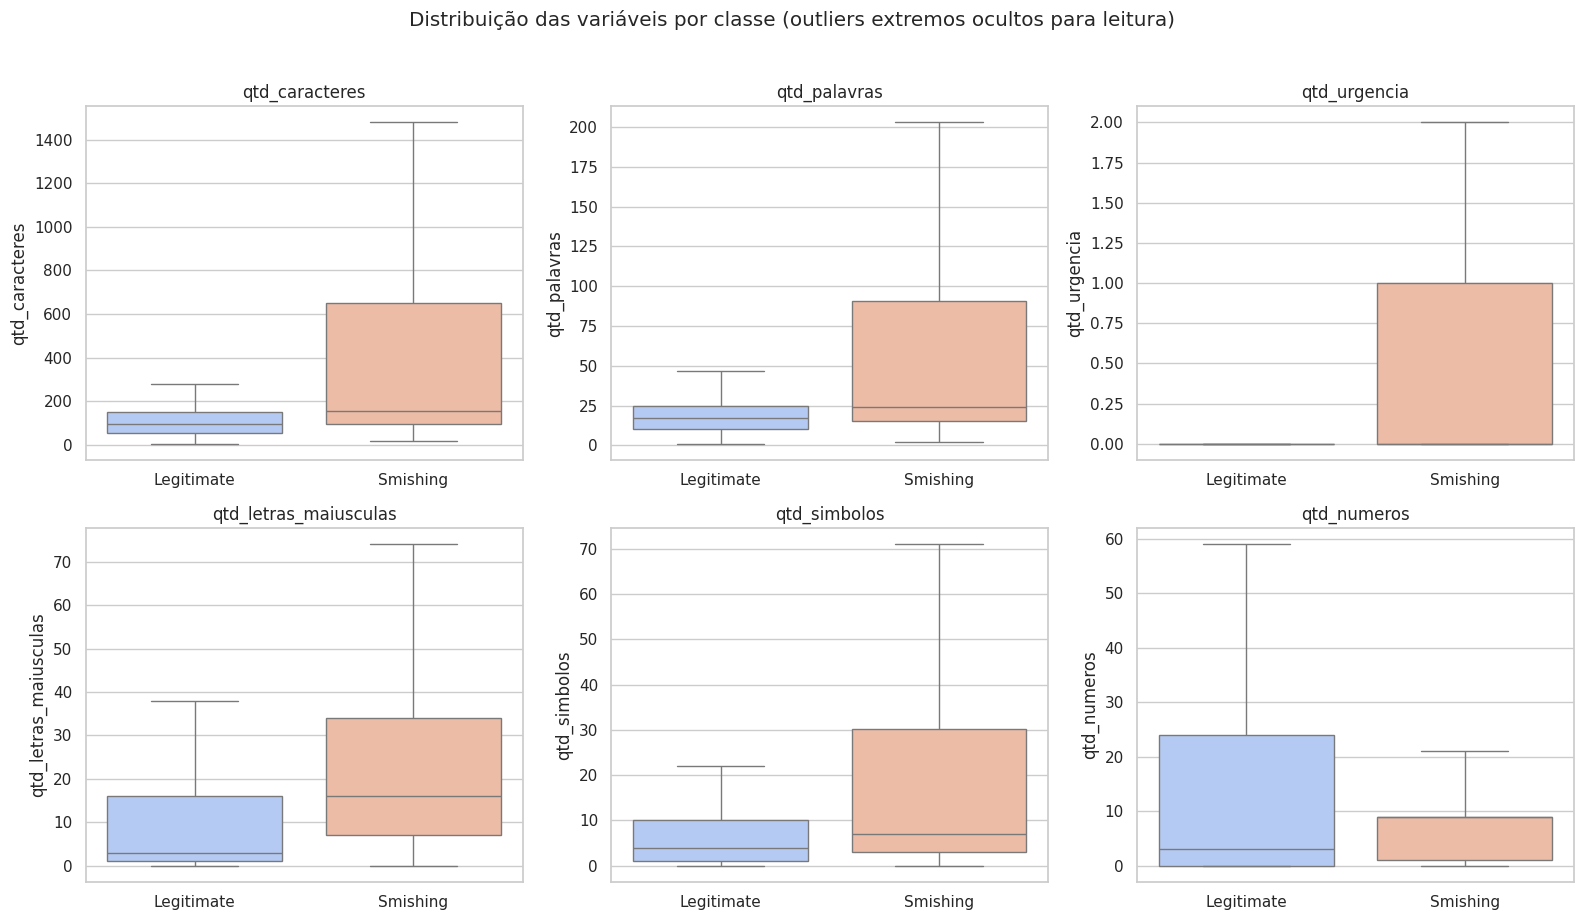

In [52]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, var in zip(axes.ravel(), vars_plot):
    sb.boxplot(x="classe", y=var, data=df, hue="classe", palette="coolwarm", legend=False, ax=ax, showfliers=False)
    ax.set_title(var)
    ax.set_xlabel("")

plt.suptitle("Distribuição das variáveis por classe (outliers extremos ocultos para leitura)", y=1.02)
plt.tight_layout()
plt.show()

comentar

### 6.2 Relação entre tamanho e número de palavras (multicolinearidade)

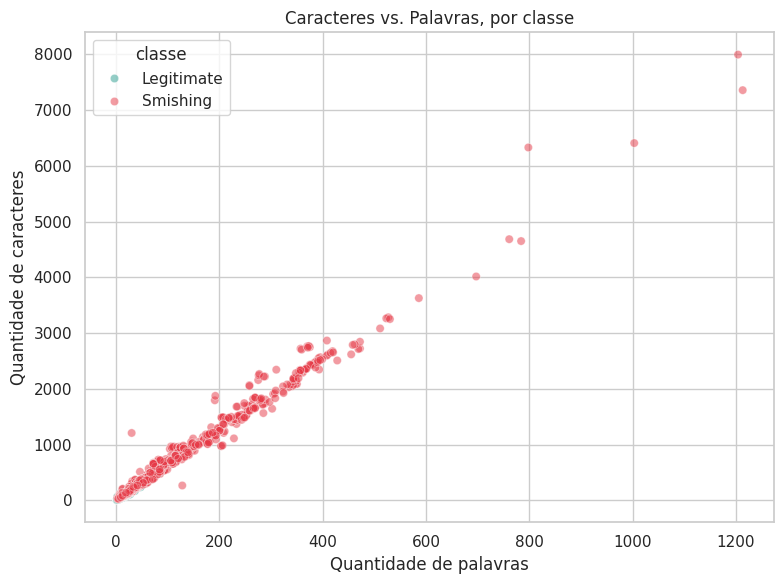

In [53]:
plt.figure(figsize=(8, 6))
sb.scatterplot(
    data=df, x="qtd_palavras", y="qtd_caracteres", hue="classe",
    alpha=0.5, palette={"Legitimate": "#2a9d8f", "Smishing": "#e63946"}
)
plt.title("Caracteres vs. Palavras, por classe")
plt.xlabel("Quantidade de palavras")
plt.ylabel("Quantidade de caracteres")
plt.tight_layout()
plt.show()

In [54]:
print("Correlação qtd_caracteres x qtd_palavras:", df["qtd_caracteres"].corr(df["qtd_palavras"]).round(3))

Correlação qtd_caracteres x qtd_palavras: 0.994


\`qtd_caracteres` e `qtd_palavras` têm correlação de ~0.99 entre si

### 6.3 Distribuição por fonte (`fonte`)

In [59]:
tab_fonte = pd.crosstab(df["fonte"], df["classe"])
tab_fonte_pct = pd.crosstab(df["fonte"], df["classe"], normalize="index").round(3) * 100

In [60]:
print("Contagem:")
display(tab_fonte)

Contagem:


classe,Legitimate,Smishing
fonte,,
fb,400,0
sms,1609,1396


In [61]:
print("Percentual dentro de cada fonte:")
display(tab_fonte_pct)

Percentual dentro de cada fonte:


classe,Legitimate,Smishing
fonte,,
fb,100.0,0.0
sms,53.5,46.5


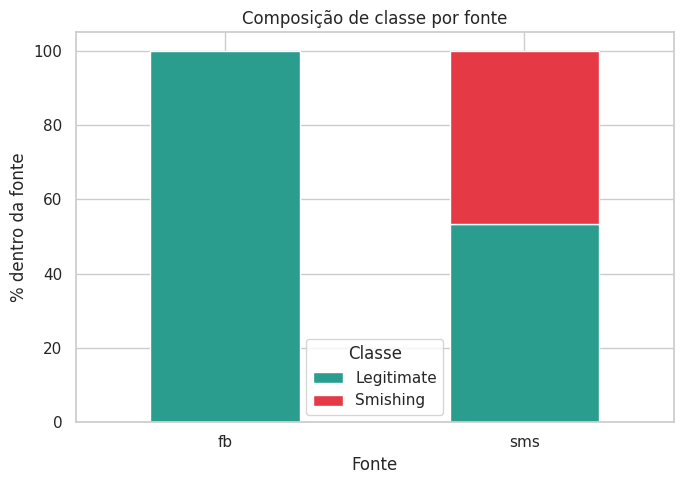

In [62]:
tab_fonte_pct.plot(kind="bar", stacked=True, figsize=(7, 5), color=["#2a9d8f", "#e63946"])
plt.title("Composição de classe por fonte")
plt.ylabel("% dentro da fonte")
plt.xlabel("Fonte")
plt.xticks(rotation=0)
plt.legend(title="Classe")
plt.tight_layout()
plt.show()

**100% das mensagens de `fonte == fb` são `Legitimate`** as mensagens de Smishing do dataset vêm de `sms`.

### 6.4 Nuvens de palavras

In [63]:
def nuvem_palavras(textos, titulo, cor_fundo="white", colormap="viridis"):
    texto_combinado = " ".join(textos.astype(str))
    wc = WordCloud(width=700, height=300, background_color=cor_fundo,
                   max_words=100, colormap=colormap).generate(texto_combinado)
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.title(titulo, fontsize=15)
    plt.axis("off")
    plt.show()

In [64]:
legit_msgs = df[df["classe"] == "Legitimate"]["texto"]
smishing_msgs = df[df["classe"] == "Smishing"]["texto"]

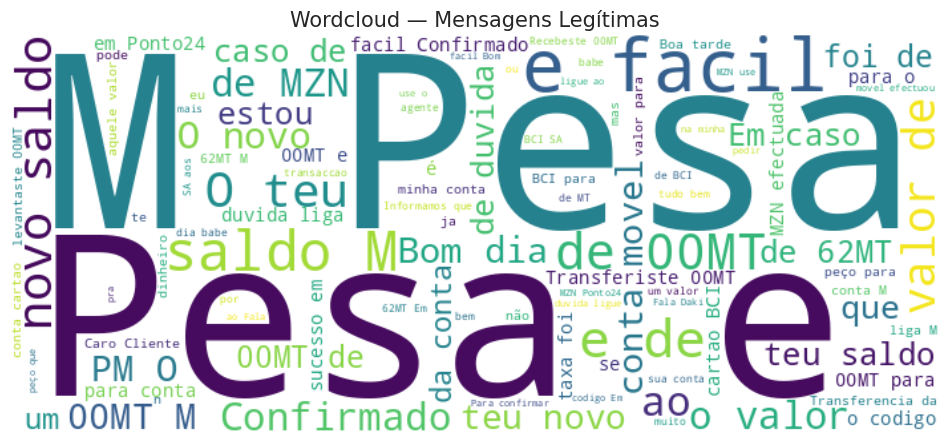

In [65]:
nuvem_palavras(legit_msgs, "Wordcloud — Mensagens Legítimas")

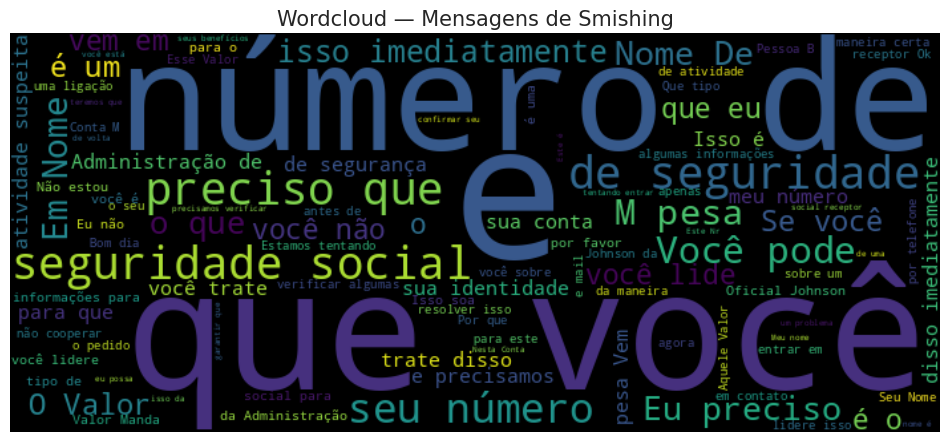

In [66]:
nuvem_palavras(smishing_msgs, "Wordcloud — Mensagens de Smishing", cor_fundo="black")

### 6.5 Palavras mais frequentes por classe

In [67]:
_stopwords_texto = (
    "a o os as de do da dos das em no na nos nas um uma uns umas para por com sem sobre entre "
    "e ou que se e sao foi ser estar esta nao sim ao aos a as seu sua seus suas meu minha meus "
    "minhas nosso nossa nossos nossas eu tu ele ela nos vos eles elas me te lhe nos vos lhes "
    "este esta estes estas esse essa esses essas aquele aquela aqueles aquelas isto isso aquilo "
    "como mais menos muito muita muitos muitas pouco pouca ja tambem mas porque quando onde qual "
    "quais ate depois antes ainda so apenas tem tens tem ter sido pela pelo pelos "
    "pela pelas num numa nele nela lhe dele dela deles delas"
)
stopwords_pt = set(_stopwords_texto.split())

In [68]:
def top_palavras(textos, n=20):
    contador = Counter()
    for t in textos.astype(str):
        palavras = re.findall(r"[a-zA-ZÀ-ÿ]{3,}", t.lower())
        contador.update(p for p in palavras if p not in stopwords_pt)
    return contador.most_common(n)

In [69]:
top_legit = pd.DataFrame(top_palavras(legit_msgs), columns=["palavra", "frequencia"])
top_smishing = pd.DataFrame(top_palavras(smishing_msgs), columns=["palavra", "frequencia"])

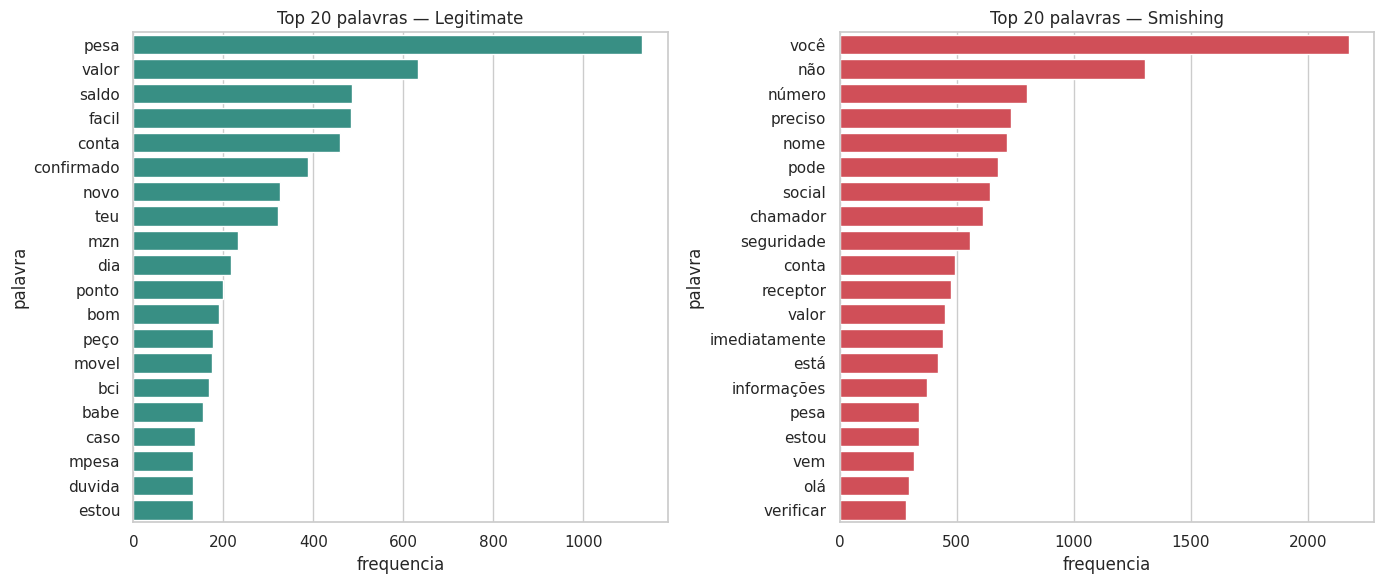

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sb.barplot(data=top_legit, y="palavra", x="frequencia", ax=axes[0], color="#2a9d8f")
axes[0].set_title("Top 20 palavras — Legitimate")
sb.barplot(data=top_smishing, y="palavra", x="frequencia", ax=axes[1], color="#e63946")
axes[1].set_title("Top 20 palavras — Smishing")
plt.tight_layout()
plt.show()

## 7. Análise de correlação

In [72]:
df["classe_bin"] = (df["classe"] == "Smishing").astype(int)

In [73]:
colunas_corr = variaveis_numericas + variaveis_binarias + ["classe_bin"]

matriz_corr = df[colunas_corr].corr(method="pearson")

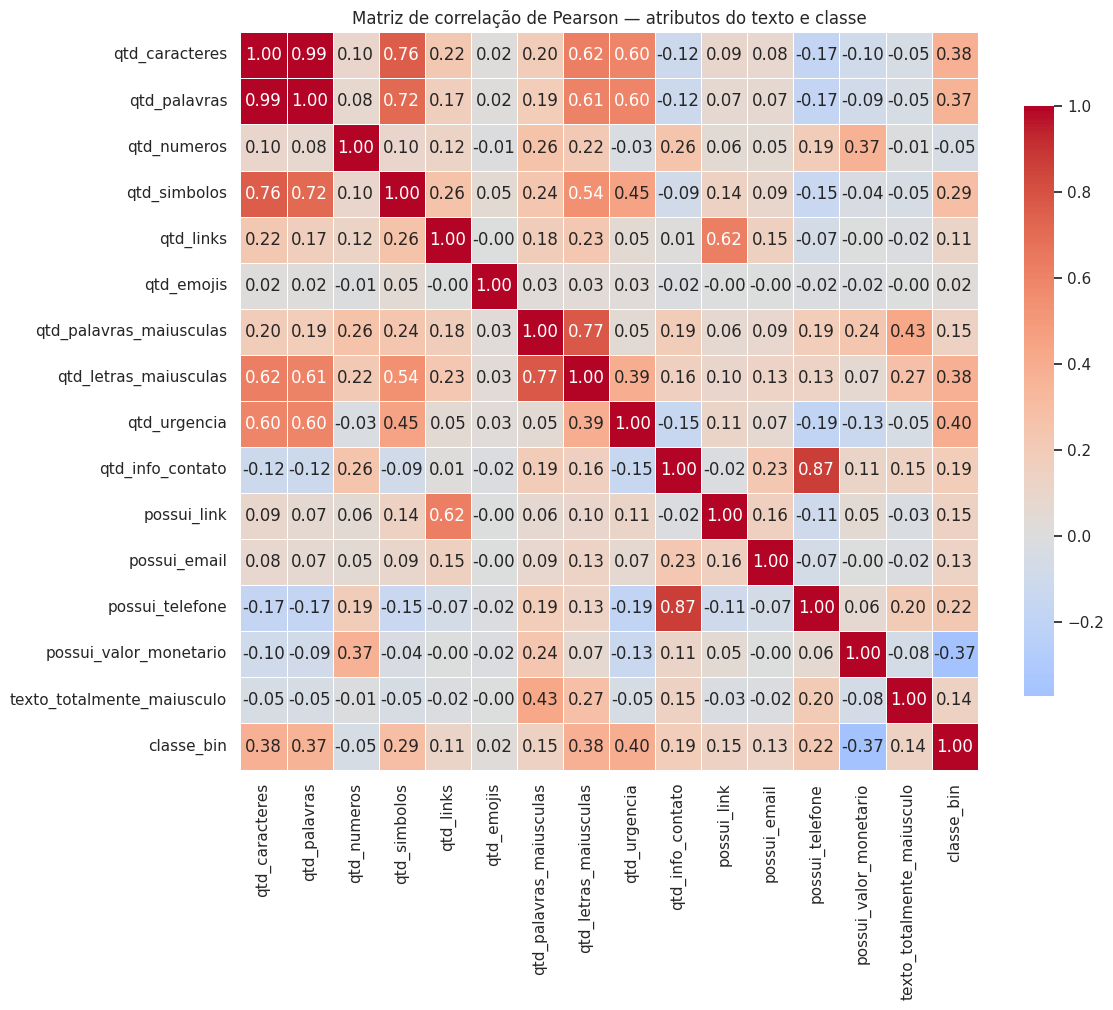

In [74]:
plt.figure(figsize=(12, 10))
sb.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
           square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Matriz de correlação de Pearson — atributos do texto e classe")
plt.tight_layout()
plt.show()

### 7.1 Correlação de cada atributo com a classe (Smishing = 1)

In [75]:
corr_pearson = matriz_corr["classe_bin"].drop("classe_bin").sort_values(key=abs, ascending=False)

corr_spearman = df[colunas_corr].corr(method="spearman")["classe_bin"].drop("classe_bin")
corr_spearman = corr_spearman.reindex(corr_pearson.index)

comparativo_corr = pd.DataFrame({
    "pearson": corr_pearson,
    "spearman": corr_spearman,
}).round(3)

In [76]:
display(comparativo_corr)

,pearson,spearman
qtd_urgencia,0.398,0.493
qtd_caracteres,0.379,0.408
qtd_letras_maiusculas,0.378,0.429
possui_valor_monetario,-0.372,-0.372
qtd_palavras,0.367,0.363
qtd_simbolos,0.287,0.288
possui_telefone,0.218,0.218
qtd_info_contato,0.187,0.239
possui_link,0.148,0.148
qtd_palavras_maiusculas,0.146,0.105


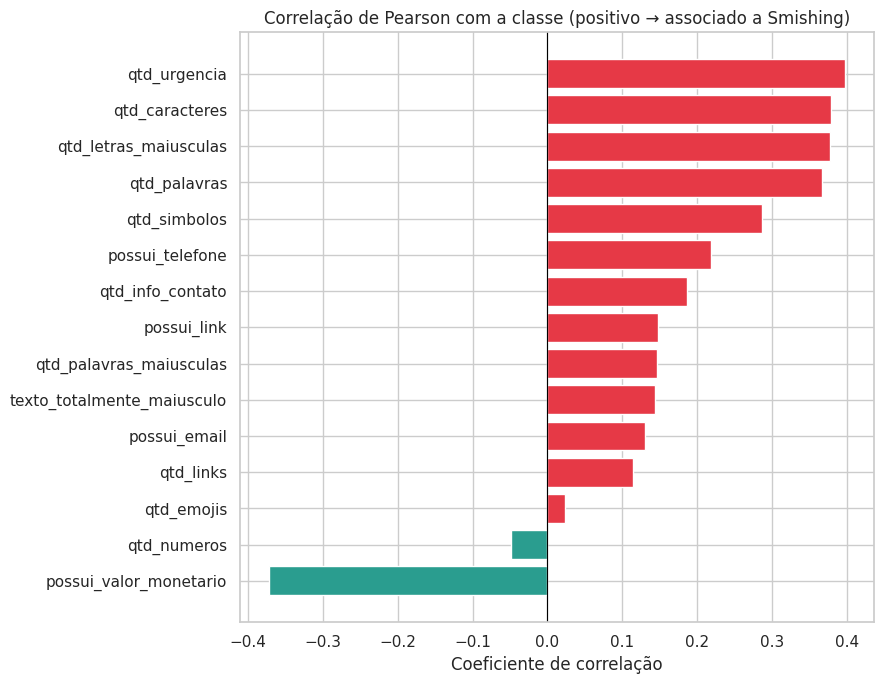

In [77]:
plt.figure(figsize=(9, 7))
ordem = comparativo_corr["pearson"].sort_values().index
plt.barh(ordem, comparativo_corr.loc[ordem, "pearson"], color=[
    "#e63946" if v > 0 else "#2a9d8f" for v in comparativo_corr.loc[ordem, "pearson"]
])
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Correlação de Pearson com a classe (positivo → associado a Smishing)")
plt.xlabel("Coeficiente de correlação")
plt.tight_layout()
plt.show()

**Leitura dos resultados** (valores reais calculados acima, arredondados):

- As correlações mais fortes com `Smishing` são **`qtd_urgencia` (~0.40)**, **`qtd_caracteres` (~0.38)**, **`qtd_letras_maiusculas` (~0.38)** e **`qtd_palavras` (~0.37)** — todas positivas: mensagens mais longas, com mais letras maiúsculas e mais vocabulário de urgência tendem a ser Smishing.
- **`possui_valor_monetario` tem correlação negativa (~-0.37)** com Smishing — ou seja, é a classe `Legitimate` que menciona valores em MT/MZN com mais frequência (consistente com confirmações reais de transação M-Pesa vistas na amostra), não o golpe.
- `qtd_numeros` tem correlação ~0 (levemente negativa), o que é coerente com o ponto anterior: números por si só (sem indicar se são valores, telefones ou códigos) não distinguem bem as classes.
- Pearson e Spearman concordam em sinal e ordem de grandeza para quase todas as variáveis, indicando que as relações não dependem fortemente de outliers extremos isolados

## 8. Conclusões

**Padrões:**
- Mensagens de Smishing tendem a ser mais longas, com mais letras maiúsculas, mais símbolos e mais vocabulário de urgência do que mensagens legítimas
- Ao contrário do que se poderia supor, é a classe `Legitimate` que menciona valores monetários (MT/MZN) com mais frequência
- `fonte == fb` é 100% `Legitimate`: essa variável concentra informação de classe para uma fatia dos dados.

**Tendências:**
- As variáveis de "volume" de texto (caracteres, palavras, símbolos) andam juntas (correlação ~0.99 entre caracteres e palavras) — comportam-se como uma única dimensão de "tamanho da mensagem", não como sinais independentes.
- `qtd_urgencia` é, isoladamente, o atributo com correlação mais forte com a classe entre os construídos manualmente, sugerindo que vocabulário de ação/urgência é o traço comportamental mais distintivo do smishing neste dataset.

**Correlação:**
- Maiores correlações (em módulo) com `Smishing`: `qtd_urgencia` (+0.40), `possui_valor_monetario` (-0.37), `qtd_caracteres` (+0.38), `qtd_letras_maiusculas` (+0.38), `qtd_palavras` (+0.37).
- A informação mútua reforça majoritariamente o mesmo ranking, com destaque para `qtd_numeros`, cuja relação com a classe é predominantemente não-linear.

